In [5]:
import numpy as np
import pandas as pd
import cv2 as cv
import torch
import matplotlib.pyplot as plt

# Item 0

In [6]:
import numpy as np

def inicializar_objetos(num_objetos, velocidade_tipica, img_size=128, seed=42):
    rng = np.random.default_rng(seed)
    objetos = []
    
    for i in range(num_objetos):
        # Direção aleatória multiplicada pela velocidade típica
        angulo_mov = rng.uniform(0, 2 * np.pi)
        vx = velocidade_tipica * np.cos(angulo_mov)
        vy = velocidade_tipica * np.sin(angulo_mov)
        
        obj = {
            'id': i + 1,  # ID único do objeto
            'center': rng.integers(20, img_size - 20, size=2).astype(float),
            'vx': vx,
            'vy': vy,
            'axes': tuple(rng.integers(8, 20, size=2).tolist()),
            'angle': int(rng.integers(0, 180)),
            'color': int(rng.integers(80, 255)),
            'z': rng.random()  # Ordem de profundidade (para oclusão)
        }
        objetos.append(obj)
        
    return objetos

In [7]:


def gerador(num_objetos=8,
             velocidade_tipica=2.0,
               dur_oclusao=10,
                num_frames = 45, 
                 img_size= (128,128) ):

    objetos = inicializar_objetos(num_objetos=num_objetos, velocidade_tipica=velocidade_tipica)
    objetos.sort(key = lambda x : x['z'])

    video_frames = []
    ground_truth =  [] # onde vai ser salvo a caixa e o ID
    for t in range(num_frames):
    #  desenhar eu não sei como faz
      frame = np.zeros((*img_size, 3), dtype=np.uint8)
      for obj in objetos:
        cx, cy = obj['center']
        rx, ry = obj['axes']
        centro_int = (int(cx), int(cy))
        cor_rgb = (obj['color'], obj['color'], obj['color'])
      
        # Desenha a elipse preenchida (-1)
        cv.ellipse(frame, centro_int, (rx, ry), obj['angle'], 0, 360, cor_rgb, -1)


        #  Calculo da bounding box
        bb_left = cx - rx
        bb_top = cy - ry
        bb_width = 2 * rx
        bb_height = 2 * ry

        # Formato MOT17: [frame, id, bb_left, bb_top, bb_width, bb_height, conf, class, visibility]
        ground_truth.append([t + 1, obj['id'], bb_left, bb_top, bb_width, bb_height, 1.0, 1, 1.0])
    
        obj['center'][0] += obj['vx']
        obj['center'][1] += obj['vy']
      

      video_frames.append(frame)


    return video_frames, ground_truth

In [8]:
def visualizar_trajetoria(video_frames, inicio =0, fim = 25, passo =2):

    quadros_para_mostrar = list(range(inicio, fim, passo))
    num_quadros = len(quadros_para_mostrar)

    fig, axes = plt.subplots(1, num_quadros, figsize = (18,23))
    for idx, frame_idx in enumerate(quadros_para_mostrar):
        axes[idx].imshow(video_frames[frame_idx])
        axes[idx].set_title(f"Quadro {frame_idx + 1}")
        axes[idx].axis('off')
        
    plt.tight_layout()
    plt.show()


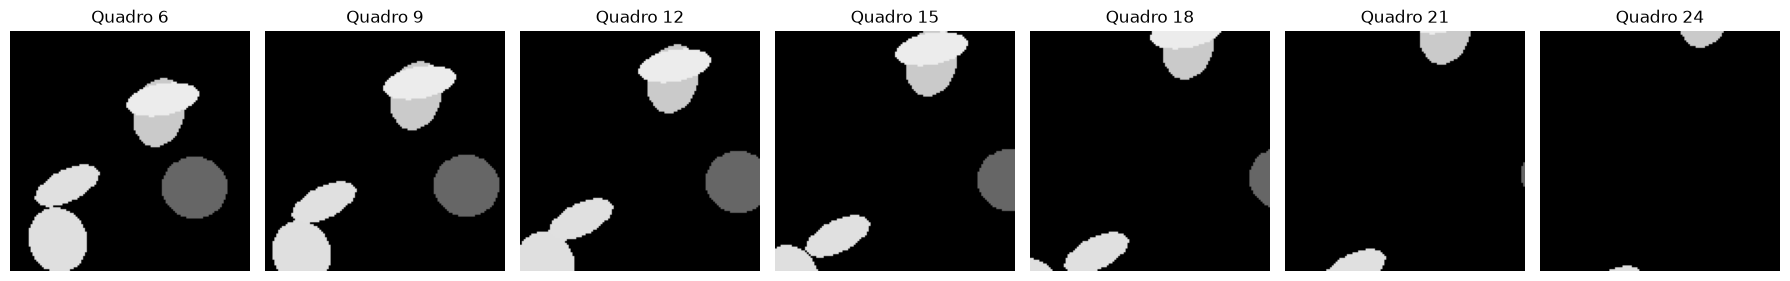

In [9]:
frames, gt = gerador(num_objetos=5, velocidade_tipica=3.0)
visualizar_trajetoria(frames, inicio=5, fim=25, passo=3)